<a href="https://colab.research.google.com/github/tarumi283/tarumi/blob/main/CircadianClock_Aging_ParameterSimulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

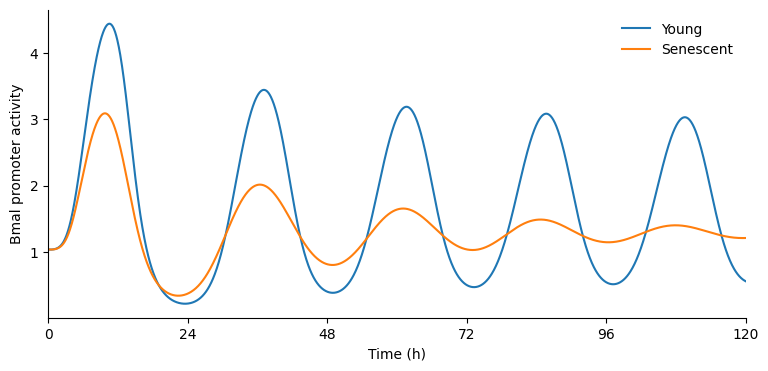

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==============================
# デフォルト（若い細胞）
# ==============================
def default_params():
    return {
        # 分解
        "dx1":0.08, "dx2":0.06, "dx3":0.09,
        "dx5":0.17, "dx6":0.12, "dx7":0.15,
        "dy1":0.3, "dy2":0.2, "dy3":2, "dy4":0.2, "dy5":1.6,
        "dz1":0.23, "dz2":0.25, "dz3":0.6, "dz4":0.2, "dz5":0.2, "dz6":0.31, "dz7":0.3, "dz8":0.73,

        # 反応
        "kfx1":2.3, "kdx1":0.01,
        "kfz4":1, "kfz5":1, "kdz5":1, "kdz4":1,
        "kfz2":2, "kdfz3":0.05,

        # 転写最大速度
        "V1max":1, "V2max":2.92, "V3max":1.90, "V4max":10.90, "V5max":1,

        # 転写定数
        "kt1":3, "kt2":2.4, "kt3":2.07, "kt4":0.9, "kt5":8.35,
        "ki1":0.9, "ki2":0.7, "ki21":5.2, "ki3":3.3, "ki4":0.4, "ki5":1.94,

        # 翻訳
        "kp1":0.4, "kp2":0.26, "kp3":0.37, "kp4":0.76, "kp5":1.21,

        # 輸送
        "kiz4":0.2, "kiz5":0.1, "kiz6":0.5, "kiz7":0.1, "kiz8":0.1,
        "kex2":0.02, "kex3":0.01,

        # Hill係数
        "a":12, "d":12, "g":5, "h":5, "i":12,
        "b":5, "c":7, "e":6, "f":4, "f1":1,
        "v":6, "w":2, "p":6, "q":3, "n":2, "m":5,

        # 恒常発現
        "Rev0":0, "Ror0":0, "Bmal0":0, "Per0":0, "Cry0":0,

        "sf":1.07
    }

# ==============================
# モデル
# ==============================
def clock_model(t, X, p):
    x = X
    dX = np.zeros(19)
    PC = x[17] + x[18]

    dX[0]  = p["sf"]*(p["kfx1"]*x[9] - p["kdx1"]*x[0] - p["dx1"]*x[0])
    dX[1]  = p["sf"]*(p["V3max"]*(1+p["g"]*(x[0]/p["kt3"])**p["v"]) /
                     (1+(PC/p["ki3"])**p["w"]*(x[0]/p["kt3"])**p["v"]+(x[0]/p["kt3"])**p["v"]) - p["dy3"]*x[1])
    dX[2]  = p["sf"]*(p["V4max"]*(1+p["h"]*(x[0]/p["kt4"])**p["p"]) /
                     (1+(PC/p["ki4"])**p["q"]*(x[0]/p["kt4"])**p["p"]+(x[0]/p["kt4"])**p["p"]) - p["dy4"]*x[2])
    dX[3]  = p["sf"]*(p["kp3"]*(x[1]+p["Rev0"]) - p["kiz6"]*x[3] - p["dz6"]*x[3])
    dX[4]  = p["sf"]*(p["kp4"]*(x[2]+p["Ror0"]) - p["kiz7"]*x[4] - p["dz7"]*x[4])
    dX[5]  = p["sf"]*(p["kiz6"]*x[3] - p["dx5"]*x[5])
    dX[6]  = p["sf"]*(p["kiz7"]*x[4] - p["dx6"]*x[6])
    dX[7]  = p["sf"]*(p["V5max"]*(1+p["i"]*(x[6]/p["kt5"])**p["n"]) /
                     (1+(x[5]/p["ki5"])**p["m"]+(x[6]/p["kt5"])**p["n"]) - p["dy5"]*x[7])
    dX[8]  = p["sf"]*(p["kp5"]*(x[7]+p["Bmal0"]) - p["kiz8"]*x[8] - p["dz8"]*x[8])
    dX[9]  = p["sf"]*(p["kiz8"]*x[8] + p["kdx1"]*x[0] - p["kfx1"]*x[9] - p["dx7"]*x[9])
    dX[10] = p["sf"]*(p["V1max"]*(1+p["a"]*(x[0]/p["kt1"])**p["b"]) /
                     (1+(PC/p["ki1"])**p["c"]*(x[0]/p["kt1"])**p["b"]+(x[0]/p["kt1"])**p["b"]) - p["dy1"]*x[10])
    dX[11] = p["sf"]*(p["V2max"]*(1+p["d"]*(x[0]/p["kt2"])**p["e"]) /
                     (1+(PC/p["ki2"])**p["f"]*(x[0]/p["kt2"])**p["e"]+(x[0]/p["kt2"])**p["e"]) *
                     (1/(1+(x[5]/p["ki21"])**p["f1"])) - p["dy2"]*x[11])
    dX[12] = p["sf"]*(p["kp2"]*(x[11]+p["Cry0"])+p["kdz4"]*x[15]+p["kdz5"]*x[16]
                     -p["kfz5"]*x[12]*x[13]-p["kfz4"]*x[12]*x[14]-p["dz1"]*x[12])
    dX[13] = p["sf"]*(p["kp1"]*(x[10]+p["Per0"])+p["kdz5"]*x[16]+p["kdfz3"]*x[14]
                     -p["kfz5"]*x[13]*x[12]-p["kfz2"]*x[13]-p["dz2"]*x[13])
    dX[14] = p["sf"]*(p["kfz2"]*x[13]+p["kdz4"]*x[15]-p["kdfz3"]*x[14]
                     -p["kfz4"]*x[14]*x[12]-p["dz3"]*x[14])
    dX[15] = p["sf"]*(p["kfz4"]*x[12]*x[14]+p["kex2"]*x[17]-p["kiz4"]*x[15]-p["kdz4"]*x[15]-p["dz4"]*x[15])
    dX[16] = p["sf"]*(p["kfz5"]*x[12]*x[13]+p["kex3"]*x[18]-p["kiz5"]*x[16]-p["kdz5"]*x[16]-p["dz5"]*x[16])
    dX[17] = p["sf"]*(p["kiz4"]*x[15]-p["kex2"]*x[17]-p["dx2"]*x[17])
    dX[18] = p["sf"]*(p["kiz5"]*x[16]-p["kex3"]*x[18]-p["dx3"]*x[18])
    return dX

# ==============================
# ★ 老化パラメータ編集エリア ★
# ==============================
young = default_params()
sen = default_params()

# ==============================
# ★ 老化パラメータ完全編集エリア ★
# ==============================

# ---- 恒常発現（basal expression）----
sen["Rev0"]  = 0.5
sen["Ror0"]  = 0.0
sen["Bmal0"] = 0.0
sen["Per0"]  = 0.0
sen["Cry0"]  = 0.0

# ---- 分解速度 ----
sen["dx1"] = 0.08
sen["dx2"] = 0.06
sen["dx3"] = 0.09
sen["dx5"] = 0.17
sen["dx6"] = 0.12
sen["dx7"] = 0.15

sen["dy1"] = 0.3
sen["dy2"] = 0.2
sen["dy3"] = 2
sen["dy4"] = 0.2
sen["dy5"] = 1.6

sen["dz1"] = 0.23
sen["dz2"] = 0.25
sen["dz3"] = 0.6
sen["dz4"] = 0.2
sen["dz5"] = 0.2
sen["dz6"] = 0.31
sen["dz7"] = 0.3
sen["dz8"] = 0.73

# ---- 複合体形成・解離 ----
sen["kfx1"] = 2.3
sen["kdx1"] = 0.01
sen["kfz4"] = 1
sen["kfz5"] = 1
sen["kdz4"] = 1
sen["kdz5"] = 1

# ---- リン酸化系 ----
sen["kfz2"]  = 2
sen["kdfz3"] = 0.05

# ---- 転写最大速度 ----
sen["V1max"] = 1
sen["V2max"] = 2.92
sen["V3max"] = 1.90
sen["V4max"] = 10.90
sen["V5max"] = 1

# ---- 転写定数 ----
sen["kt1"] = 3
sen["kt2"] = 2.4
sen["kt3"] = 2.07
sen["kt4"] = 0.9
sen["kt5"] = 8.35

sen["ki1"]  = 0.9
sen["ki2"]  = 0.7
sen["ki21"] = 5.2
sen["ki3"]  = 3.3
sen["ki4"]  = 0.4
sen["ki5"]  = 1.94

# ---- 翻訳速度 ----
sen["kp1"] = 0.4
sen["kp2"] = 0.26
sen["kp3"] = 0.37
sen["kp4"] = 0.76
sen["kp5"] = 1.21

# ---- 核輸送 ----
sen["kiz4"] = 0.2
sen["kiz5"] = 0.1
sen["kiz6"] = 0.5
sen["kiz7"] = 0.1
sen["kiz8"] = 0.1

sen["kex2"] = 0.02
sen["kex3"] = 0.01

# ---- Hill係数 ----
sen["a"] = 12
sen["d"] = 12
sen["g"] = 5
sen["h"] = 5
sen["i"] = 12

sen["b"]  = 5
sen["c"]  = 7
sen["e"]  = 6
sen["f"]  = 4
sen["f1"] = 1

sen["v"] = 6
sen["w"] = 2
sen["p"] = 6
sen["q"] = 3
sen["n"] = 2
sen["m"] = 5

# ---- 時間スケール ----
sen["sf"] = 1.07


# ==============================
# 実行
# ==============================
def run_sim(p):
    X0 = np.full(19, 0.5)
    X0[0] = 1.0
    t_eval = np.linspace(0,120,2400)
    sol = solve_ivp(clock_model,(0,120),X0,t_eval=t_eval,args=(p,))
    return sol.t, sol.y

def bmal_promoter(y,p):
    return p["V5max"]*(1+p["i"]*(y[6]/p["kt5"])**p["n"]) / \
           (1+(y[5]/p["ki5"])**p["m"]+(y[6]/p["kt5"])**p["n"])

tY,yY = run_sim(young)
tS,yS = run_sim(sen)

lucY = bmal_promoter(yY,young)
lucS = bmal_promoter(yS,sen)

plt.figure(figsize=(9,4))
ax = plt.gca()
plt.plot(tY,lucY,label="Young")
plt.plot(tS,lucS,label="Senescent")
plt.xlabel("Time (h)")
plt.ylabel("Bmal promoter activity")
plt.xlim(0,120)
plt.xticks(np.arange(0,121,24))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(frameon=False)
plt.show()
